In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# DATASET LOADING 
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
columns = ["age","sex","cp","trestbps","chol","fbs", "restecg","thalach","exang","oldpeak", "slope","ca","thal","target"]
df = pd.read_csv(url, names=columns)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
print("Shape of dataset:", df.shape)
print("Size of dataset:", df.shape[0]*df.shape[1])

Shape of dataset: (303, 14)
Size of dataset: 4242


In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [6]:
# Unique values in dataset (to find types of features -> binary/categorical/numerical)
for i in df:    
    print(df[i].name,":",df[i].unique())

age : [63. 67. 37. 41. 56. 62. 57. 53. 44. 52. 48. 54. 49. 64. 58. 60. 50. 66.
 43. 40. 69. 59. 42. 55. 61. 65. 71. 51. 46. 45. 39. 68. 47. 34. 35. 29.
 70. 77. 38. 74. 76.]
sex : [1. 0.]
cp : [1. 4. 3. 2.]
trestbps : [145. 160. 120. 130. 140. 172. 150. 110. 132. 117. 135. 112. 105. 124.
 125. 142. 128. 170. 155. 104. 180. 138. 108. 134. 122. 115. 118. 100.
 200.  94. 165. 102. 152. 101. 126. 174. 148. 178. 158. 192. 129. 144.
 123. 136. 146. 106. 156. 154. 114. 164.]
chol : [233. 286. 229. 250. 204. 236. 268. 354. 254. 203. 192. 294. 256. 263.
 199. 168. 239. 275. 266. 211. 283. 284. 224. 206. 219. 340. 226. 247.
 167. 230. 335. 234. 177. 276. 353. 243. 225. 302. 212. 330. 175. 417.
 197. 198. 290. 253. 172. 273. 213. 305. 216. 304. 188. 282. 185. 232.
 326. 231. 269. 267. 248. 360. 258. 308. 245. 270. 208. 264. 321. 274.
 325. 235. 257. 164. 141. 252. 255. 201. 222. 260. 182. 303. 265. 309.
 307. 249. 186. 341. 183. 407. 217. 288. 220. 209. 227. 261. 174. 281.
 221. 205. 240. 289. 31

In [7]:
# statistical analysis
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


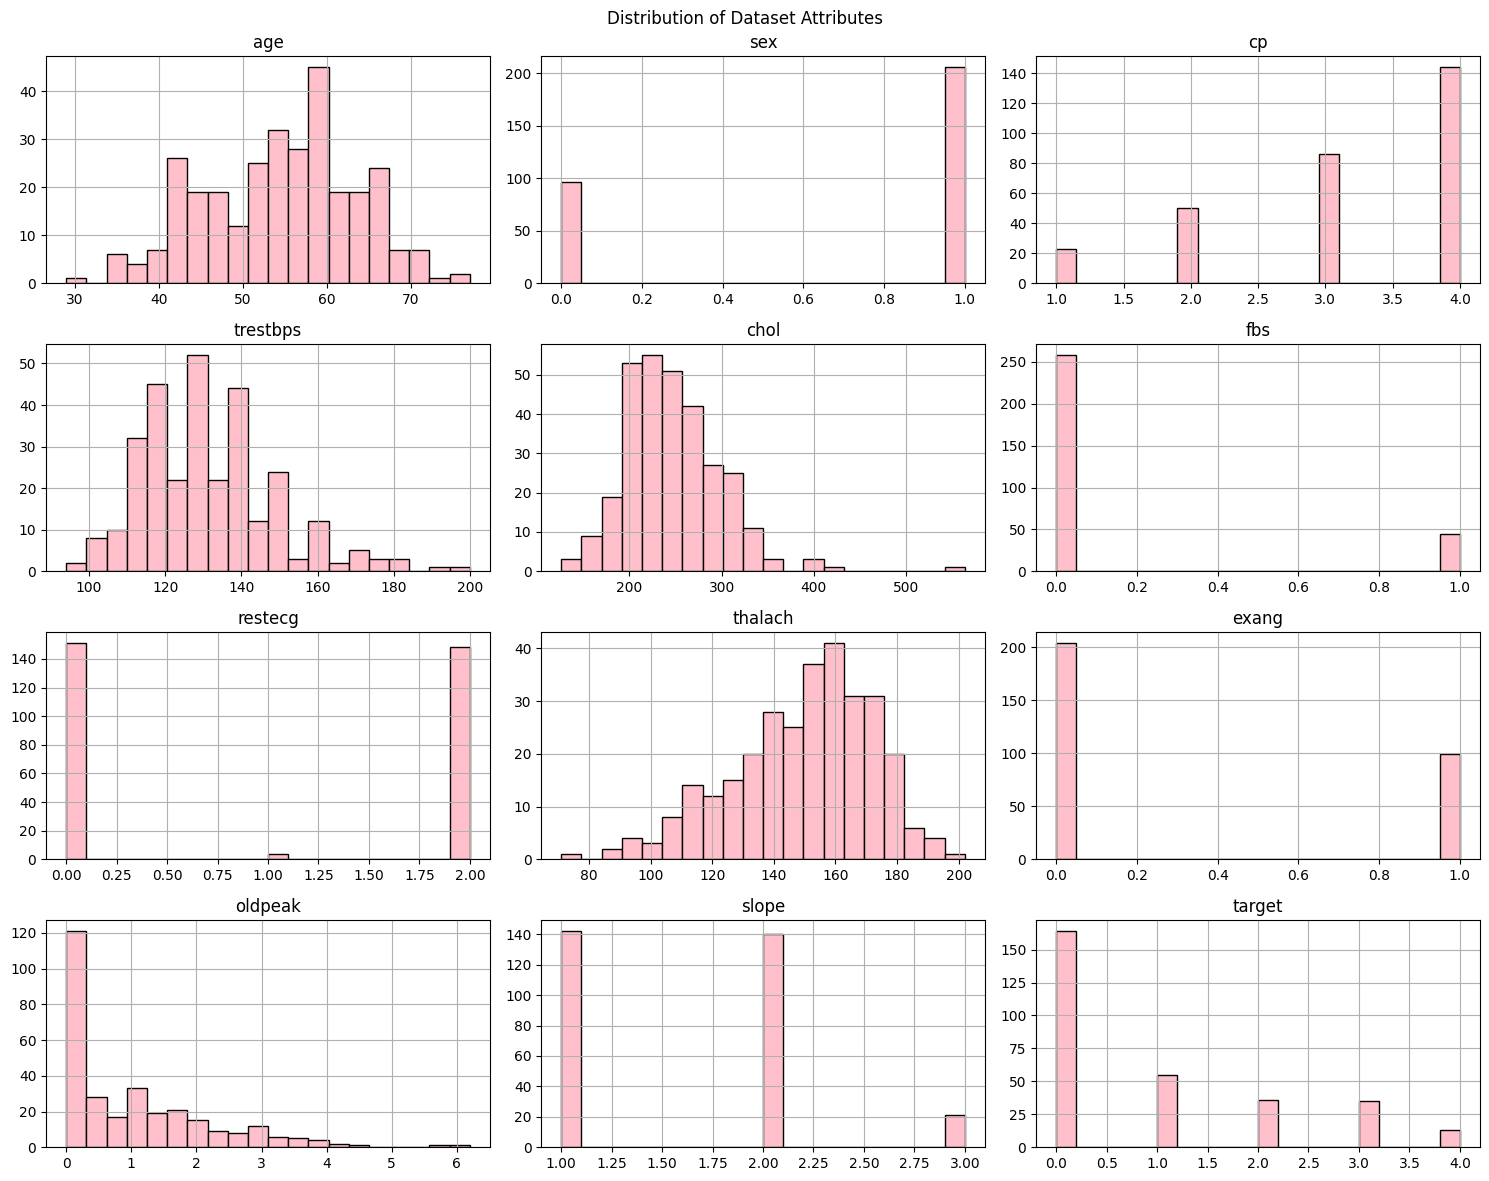

In [8]:
# Distribution Plots: Visualizing how the data is spread out 
df.hist(figsize=(15, 12), bins=20, color='pink', edgecolor='black')
plt.suptitle("Distribution of Dataset Attributes")
plt.tight_layout()
plt.show()

In [9]:
# Missing values in ca and thal
df.replace('?', np.nan, inplace=True)
df = df.apply(pd.to_numeric)
print("Missing values per column before imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column before imputation:
ca      4
thal    2
dtype: int64


In [10]:
from sklearn.impute import SimpleImputer
# Fills missing spots with the middle value of that column
imputer_median = SimpleImputer(strategy='median')
df_median = pd.DataFrame(imputer_median.fit_transform(df), columns=df.columns)

In [11]:
print("\nTotal missing values in KNN dataset after imputation:", df_median.isnull().sum().sum())


Total missing values in KNN dataset after imputation: 0


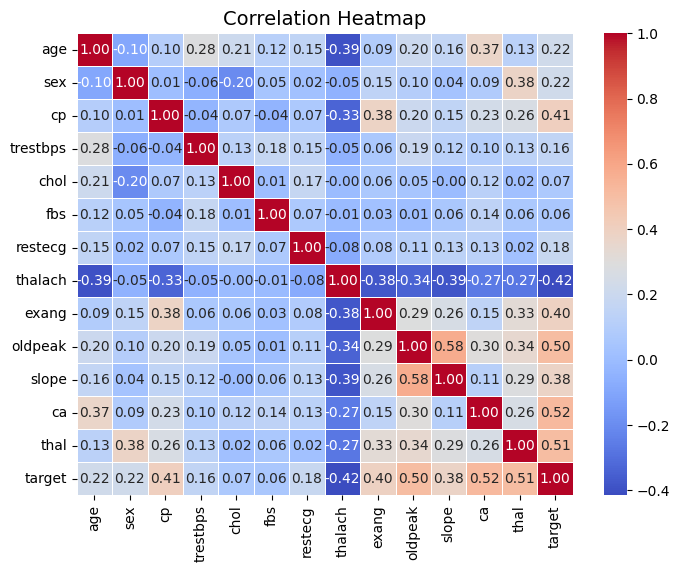

In [12]:
# correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_median.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=14)
plt.show()

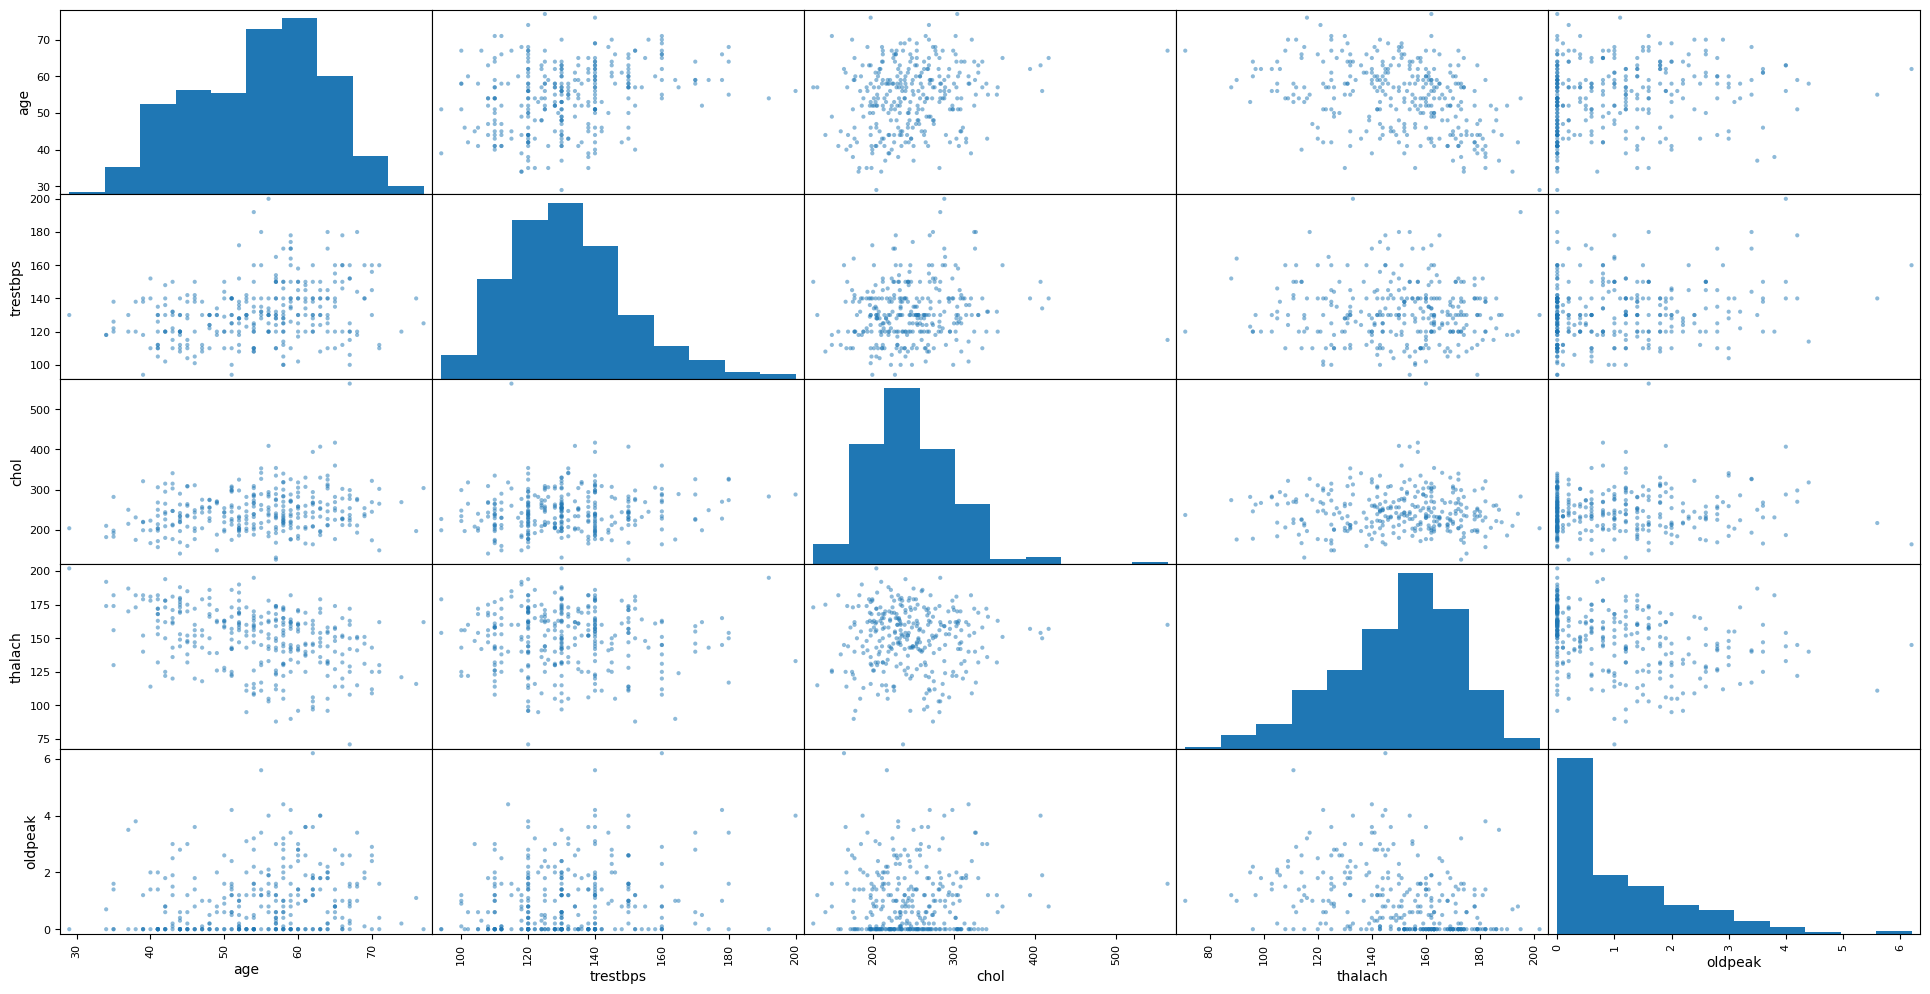

In [13]:
corr_matrix = df.corr(method='pearson')
from pandas.plotting import scatter_matrix
attributes = ['age','trestbps','chol','thalach','oldpeak']
scatter_matrix(df[attributes], figsize=(24, 12))
plt.show()

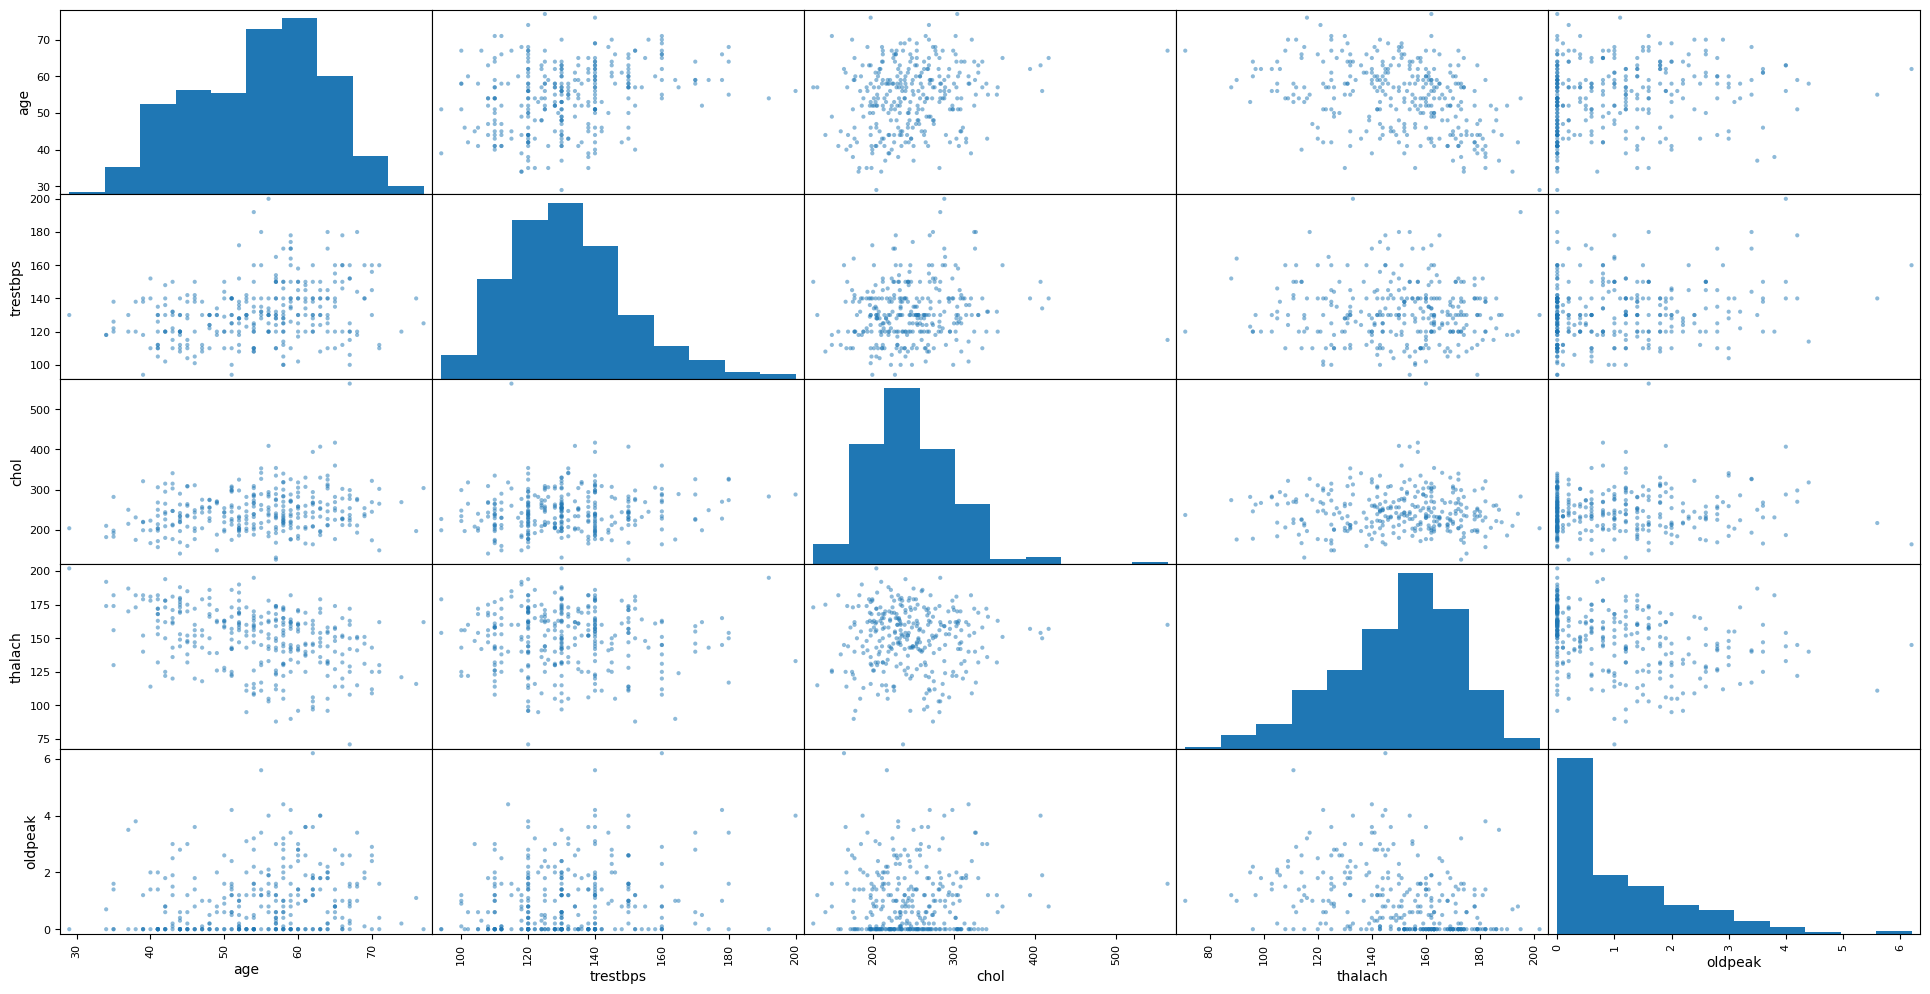

In [14]:
corr_matrix = df.corr(method='spearman')
from pandas.plotting import scatter_matrix
attributes = ['age','trestbps','chol','thalach','oldpeak']
scatter_matrix(df[attributes], figsize=(24, 12))
plt.show()

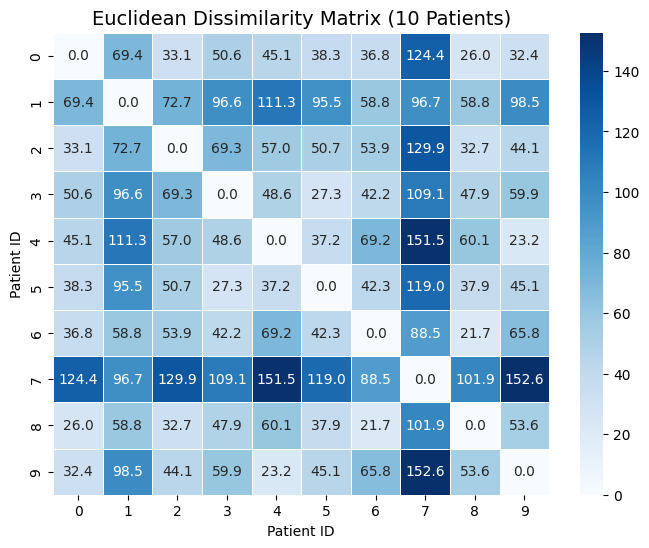

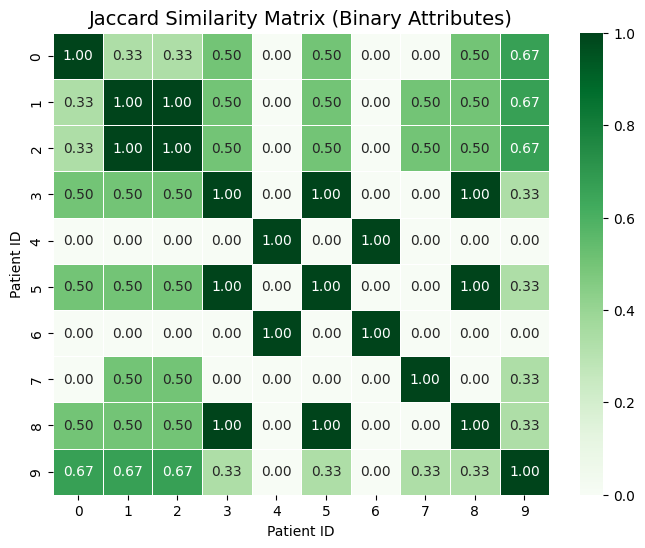

In [ ]:
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity
from sklearn.metrics import pairwise_distances
import seaborn as sns
import matplotlib.pyplot as plt

df_sample = df.head(10)

numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
binary_cols = ['sex', 'fbs', 'exang']

euclidean_matrix = euclidean_distances(df_sample[numerical_cols])

# Cosine Similarity 
# Dissimilarity = 1 - Similarity
cosine_sim_matrix = cosine_similarity(df_sample[numerical_cols])
cosine_dissim_matrix = 1 - cosine_sim_matrix

# Jaccard Distance Matrix (for binary attributes)
jaccard_data = df_sample[binary_cols].astype(bool)
jaccard_array = jaccard_data.to_numpy()
jaccard_distance_matrix = pairwise_distances(jaccard_array, metric='jaccard')
jaccard_similarity_matrix = 1 - jaccard_distance_matrix

plt.figure(figsize=(8, 6))
sns.heatmap(euclidean_matrix, annot=True, cmap='Blues', fmt=".1f", linewidths=0.5)
plt.title("Euclidean Dissimilarity Matrix (10 Patients)", fontsize=14)
plt.xlabel("Patient ID")
plt.ylabel("Patient ID")
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(jaccard_similarity_matrix, annot=True, cmap='Greens', fmt=".2f", linewidths=0.5)
plt.title("Jaccard Similarity Matrix (Binary Attributes)", fontsize=14)
plt.xlabel("Patient ID")
plt.ylabel("Patient ID")
plt.show()

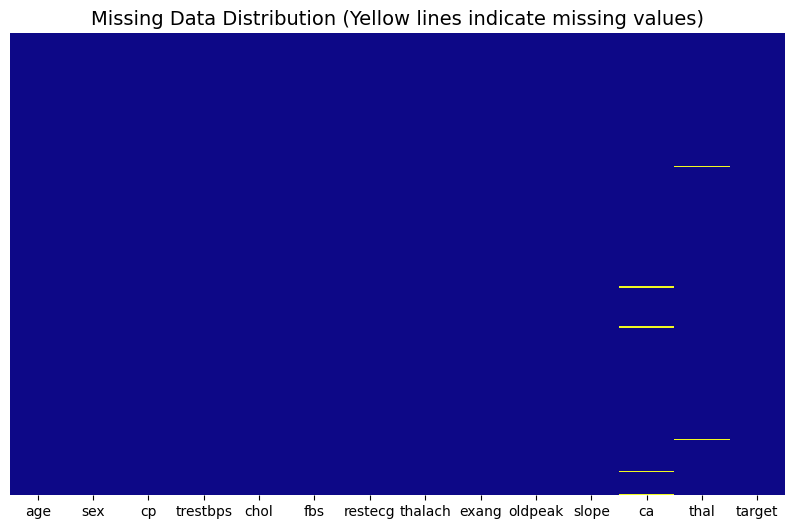

Missing Values Count:
ca      4
thal    2
dtype: int64


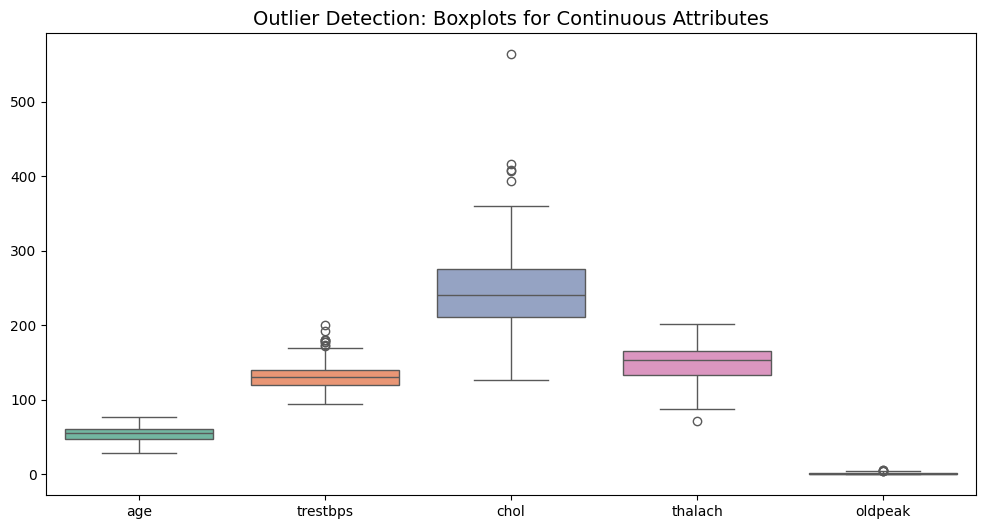

Unique Values in Categorical Columns
sex: [1. 0.]
cp: [1. 4. 3. 2.]
fbs: [1. 0.]
restecg: [2. 0. 1.]
exang: [0. 1.]
slope: [3. 2. 1.]
thal: [ 6.  3.  7. nan]
Correlation with Target Variable
target      1.000000
ca          0.518909
thal        0.509923
oldpeak     0.504092
cp          0.407075
exang       0.397057
slope       0.377957
sex         0.224469
age         0.222853
restecg     0.183696
trestbps    0.157754
chol        0.070909
fbs         0.059186
thalach    -0.415040
Name: target, dtype: float64


In [29]:
# The UCI dataset uses '?' for missing data. We must convert this to standard NaN.
df.replace('?', np.nan, inplace=True)

df['ca'] = pd.to_numeric(df['ca'])
df['thal'] = pd.to_numeric(df['thal'])

# Visualization showing missing data distribution
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='plasma', yticklabels=False)
plt.title('Missing Data Distribution (Yellow lines indicate missing values)', fontsize=14)
plt.show()

print("Missing Values Count:")
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0])

# Boxplots are the best way to visualize outliers in continuous numerical data
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[continuous_cols], palette='Set2')
plt.title('Outlier Detection: Boxplots for Continuous Attributes', fontsize=14)
plt.show()

print("Unique Values in Categorical Columns")
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

print("Correlation with Target Variable")
print(df.corr()['target'].sort_values(ascending=False))

In [32]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

df.replace('?', np.nan, inplace=True)
df['ca'] = pd.to_numeric(df['ca'])
df['thal'] = pd.to_numeric(df['thal'])

# Verify missing values exist before imputation
print("Missing values before imputation:\n", df.isnull().sum()[df.isnull().sum() > 0])

# Median Imputation 
# Replaces NaN with the median of that specific column
imputer_median = SimpleImputer(strategy='median')
df_median = pd.DataFrame(imputer_median.fit_transform(df), columns=df.columns)

# KNN Imputation 
# Replaces NaN based on the average of the 'k' most similar patients
imputer_knn = KNNImputer(n_neighbors=5)
df_knn = pd.DataFrame(imputer_knn.fit_transform(df), columns=df.columns)

# Iterative Imputation 
# Models each feature with missing values as a function of other features
imputer_iterative = IterativeImputer(max_iter=10, random_state=42)
df_iterative = pd.DataFrame(imputer_iterative.fit_transform(df), columns=df.columns)

print("\nMissing values in KNN dataset after imputation:\n", df_knn.isnull().sum().sum())

Missing values before imputation:
 ca      4
thal    2
dtype: int64

Missing values in KNN dataset after imputation:
 0


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df.replace('?', np.nan, inplace=True)
df['ca'] = pd.to_numeric(df['ca'])
df['thal'] = pd.to_numeric(df['thal'])

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing Pipeline
# The pipeline chains together the steps sequentially
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Step 1: Handle missing values
    ('scaler', StandardScaler()),                  # Step 2: Scale the data
    ('classifier', LogisticRegression())           # Step 3: Train the model
])

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)

print(f"Pipeline Accuracy: {accuracy_score(y_test, predictions):.2f}")

Pipeline Accuracy: 0.54
